In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("kc_house_data.csv")

In [3]:
df = df.drop(["id","date"], axis = 1)
df = df.dropna()

In [4]:
x = df.drop("price", axis = 1)
y = df["price"]

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [6]:
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
y_pred = model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [8]:
print("MSE: ", mse)
print("rmse: ", rmse)
print("R2: ", r2)

MSE:  45173046132.79241
rmse:  212539.51663818286
R2:  0.7011904448878263


In [9]:
print("Model Coefficient: ", model.coef_)
print("Model Intercept: ", model.intercept_)

Model Coefficient:  [-3.43354187e+04  4.45645289e+04  1.09015817e+02  8.88473539e-02
  7.00312952e+03  5.62413070e+05  5.36411070e+04  2.45267101e+04
  9.45678917e+04  7.00227409e+01  3.89930758e+01 -2.68076890e+03
  2.04156328e+01 -5.52253038e+02  5.95968122e+05 -1.94585724e+05
  2.12143306e+01 -3.25831873e-01]
Model Intercept:  6643873.527887721


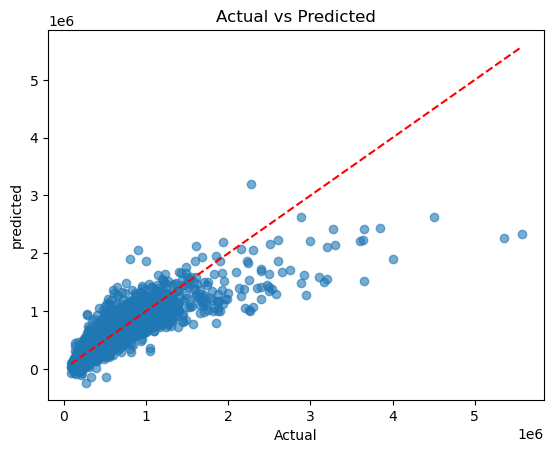

In [10]:
plt.scatter(y_test, y_pred, alpha = 0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual")
plt.ylabel("predicted")
plt.title("Actual vs Predicted")
plt.show()